# Notebook 02: Model Evaluation & Metrics Analysis

**Goal**: Evaluate the trained transfer learning model (`MobileNetV2`) on the held-out test split dataset. Calculate Accuracy, Precision, Recall, F1-Score, plot the Confusion Matrix, and visualize per-class predictions and confidence scores.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Add repository root to path
REPO_ROOT = Path("..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from src.utils.config import Config
from src.utils.seed import set_seed
from src.preprocessing.dataset import get_dataloaders
from src.models.classifier import TomatoDiseaseClassifier
from src.evaluation.metrics import (
    calculate_metrics,
    print_classification_report,
    plot_confusion_matrix
)

set_seed(Config.SEED)


[INFO] Random seed set to: 42


## 1. Load Model Checkpoint & Test Dataset


In [2]:
model_path = Config.DEFAULT_MODEL_SAVE_PATH
if not model_path.exists():
    raise FileNotFoundError(f"Checkpoint not found at: {model_path}. Run train.py first.")

checkpoint = torch.load(model_path, map_location="cpu")
model_name = checkpoint.get("model_name", Config.DEFAULT_MODEL_NAME)
class_names = checkpoint.get("class_names", Config.TARGET_CLASSES)

model = TomatoDiseaseClassifier(num_classes=len(class_names), model_name=model_name, pretrained=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Loaded '{model_name}' checkpoint from epoch {checkpoint.get('epoch', 'N/A')}.")

_, _, test_loader = get_dataloaders(batch_size=Config.BATCH_SIZE, seed=Config.SEED)
print(f"Test dataset loaded with {len(test_loader.dataset)} samples.")


Loaded 'mobilenet_v2' checkpoint from epoch 3.
Test dataset loaded with 24 samples.


## 2. Run Test Inference & Compute Metrics


In [3]:
y_true = []
y_pred = []
probs_list = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(labels.numpy().tolist())
        y_pred.extend(preds.numpy().tolist())
        probs_list.extend(probs.numpy().tolist())

metrics = calculate_metrics(y_true, y_pred, class_names=class_names)
print_classification_report(y_true, y_pred, class_names=class_names)


           TOMATO CROP DISEASE CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Healthy     1.0000    1.0000    1.0000         6
Early Blight     1.0000    1.0000    1.0000         6
 Late Blight     1.0000    1.0000    1.0000         6
   Leaf Mold     1.0000    1.0000    1.0000         6

    accuracy                         1.0000        24
   macro avg     1.0000    1.0000    1.0000        24
weighted avg     1.0000    1.0000    1.0000        24



## 3. Confusion Matrix Plot


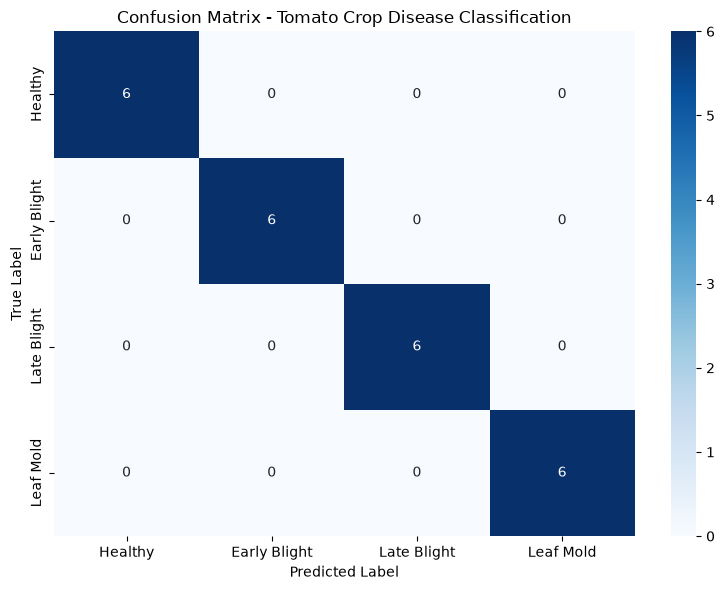

In [4]:
plot_confusion_matrix(metrics["confusion_matrix"], class_names=class_names, show=True)


## 4. Per-Class Precision, Recall, and F1-Score Breakdown


       Class  Precision  Recall  F1-Score
     Healthy        1.0     1.0       1.0
Early Blight        1.0     1.0       1.0
 Late Blight        1.0     1.0       1.0
   Leaf Mold        1.0     1.0       1.0


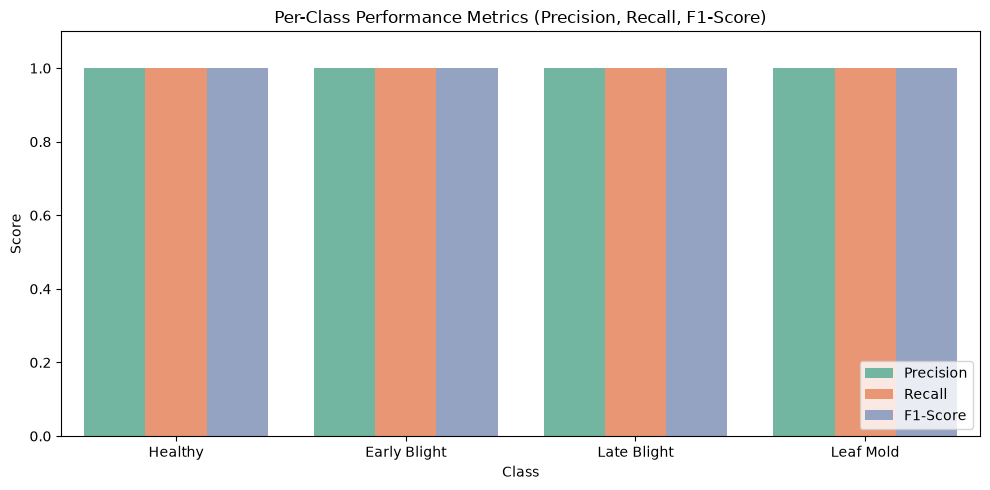

In [5]:
df_per_class = metrics["per_class"]
print(df_per_class.to_string(index=False))

df_melted = df_per_class.melt(id_vars=["Class"], value_vars=["Precision", "Recall", "F1-Score"], var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 5))
sns.barplot(data=df_melted, x="Class", y="Score", hue="Metric", palette="Set2")
plt.ylim(0, 1.1)
plt.title("Per-Class Performance Metrics (Precision, Recall, F1-Score)")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 5. Sample Test Predictions Visualization


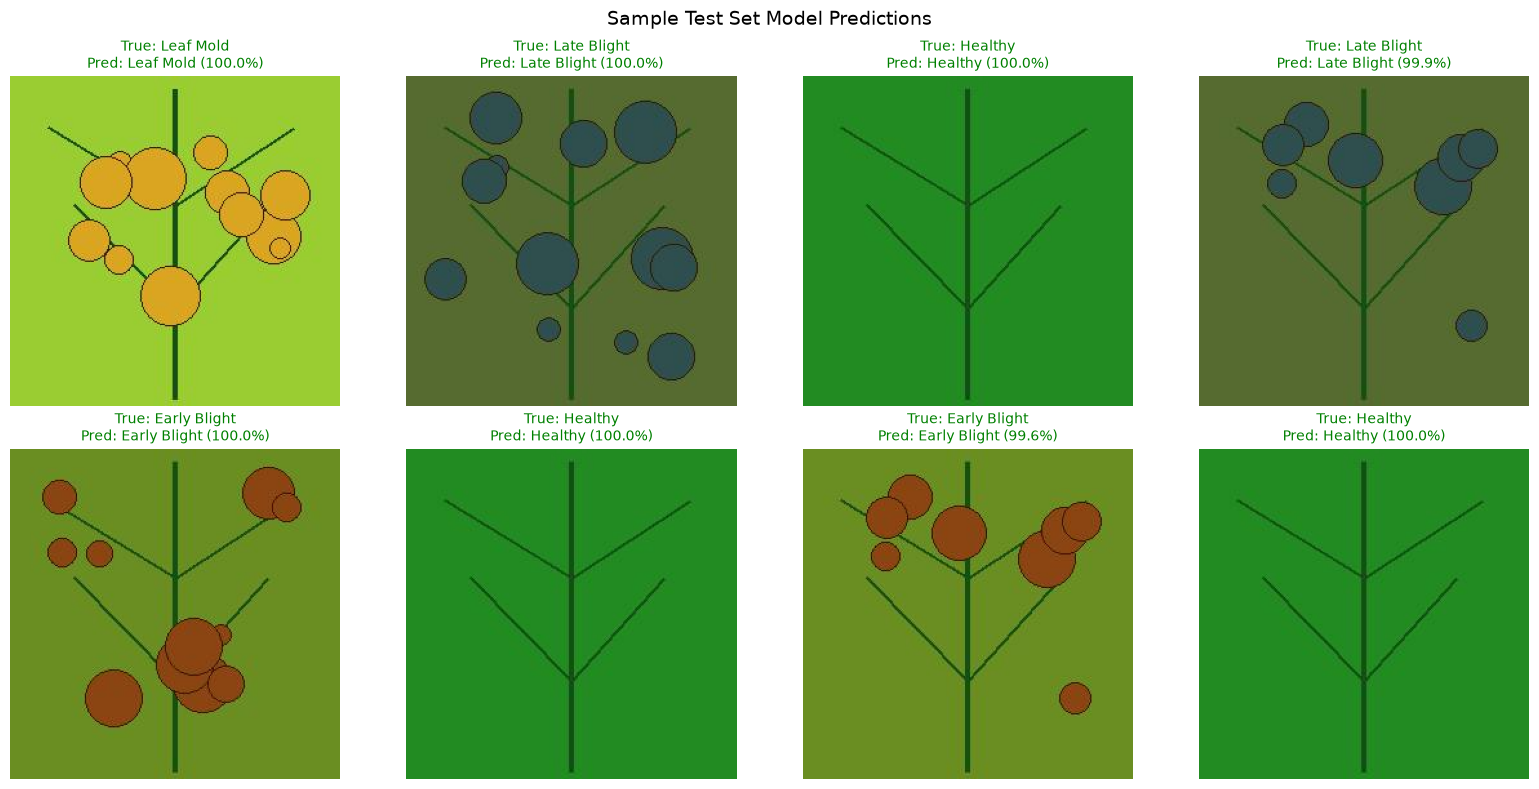

In [6]:
test_df = pd.read_csv(Config.SPLITS_CSV_PATH)
test_df = test_df[test_df["split"] == "test"].reset_index(drop=True)

sample_indices = np.random.choice(len(test_df), min(8, len(test_df)), replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    row = test_df.iloc[idx]
    img_path = row["image_path"]
    true_label = row["class_name"]
    
    pred_result = model.predict_file(img_path)
    pred_label = pred_result["predicted_disease"]
    conf = pred_result["confidence"]
    
    img = Image.open(img_path)
    axes[i].imshow(img)
    color = "green" if true_label == pred_label else "red"
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label} ({conf*100:.1f}%)", color=color, fontsize=10)
    axes[i].axis("off")

plt.suptitle("Sample Test Set Model Predictions", fontsize=14)
plt.tight_layout()
plt.show()
